In [35]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.phase_space import k_hamiltonian_generator, analyse_hk
from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
from koala.graph_color import color_lattice
import numpy as np

from matplotlib import pyplot as plt


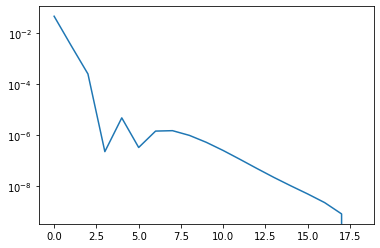

In [40]:


points = uniform(5)
lattice = generate_lattice(points)
J = np.array([1,1,1])
target_fluxes = np.array([-1]*lattice.n_plaquettes)
ujk = ujk_from_fluxes(lattice, target_fluxes)

coloring = color_lattice(lattice)
Hk = k_hamiltonian_generator(lattice, coloring,ujk,J)

e_vals = []
g_vals = []
for phase_resolution in range(1, 20):
    e, g = analyse_hk(Hk, phase_resolution)
    e_vals.append(e)
    g_vals.append(g)

plt.plot(np.abs(e_vals - e_vals[-1]))
# plt.plot(np.abs(g_vals - g_vals[-1]))

plt.yscale('log')
